In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [3]:
!ls /content/drive/MyDrive/data_paisajes/

PROF_seg_test.zip  PROF_seg_train.zip


In [1]:
class_names = ['mountain','street','glacier', 'buildings','sea','forest']

IMAGE_SIZE = (100,100)

In [2]:
class_names_label = {class_name:i for i ,class_name in enumerate(class_names)}
class_names_label

{'mountain': 0,
 'street': 1,
 'glacier': 2,
 'buildings': 3,
 'sea': 4,
 'forest': 5}

In [3]:
import cv2

In [4]:
!pip install opencv-python

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT_PATH = os.getcwd()
TRAIN_PATH = Path(ROOT_PATH) / "seg_train"
TEST_PATH = Path(ROOT_PATH) / "seg_test"

In [5]:
def read_data(path, im_size, class_names_label):
    X = []
    y = []

    for folder in os.listdir(path):
        label = class_names_label[folder]
        folder_path = os.path.join(path,folder)
        # Iterar sobre todo lo que haya en path
        for file in os.listdir(folder_path):
            image_path = os.path.join(folder_path,file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, im_size)
            X.append(image)
            y.append(label)


    return np.array(X), np.array(y)


X_train, y_train = read_data("seg_train", IMAGE_SIZE, class_names_label)
X_test, y_test = read_data("seg_test", IMAGE_SIZE, class_names_label)

print(X_train.shape)
print(X_test.shape)

(14034, 100, 100, 3)
(3000, 100, 100, 3)


In [8]:
import torch

# Verifica si CUDA está disponible
print(f"¿CUDA disponible?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    # Crea un tensor y pásalo a la GPU
    device = torch.device("cuda")
    x = torch.randn(10000, 10000, device=device)
    y = torch.matmul(x, x)
    print("Tensor procesado en GPU.")

¿CUDA disponible?: True
Tensor procesado en GPU.


In [11]:
print(y_train.shape)
print(y_test.shape)

(14034,)
(3000,)


In [12]:
y_train

array([3, 3, 3, ..., 1, 1, 1], shape=(14034,))

In [14]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [15]:
y_train[0:10]

array([3, 1, 1, 4, 0, 2, 0, 0, 3, 1])

In [18]:
pd.DataFrame(y_train).value_counts()

0
0    2512
2    2404
1    2382
4    2274
5    2271
3    2191
Name: count, dtype: int64

In [19]:
X_train.max()

np.uint8(255)

street


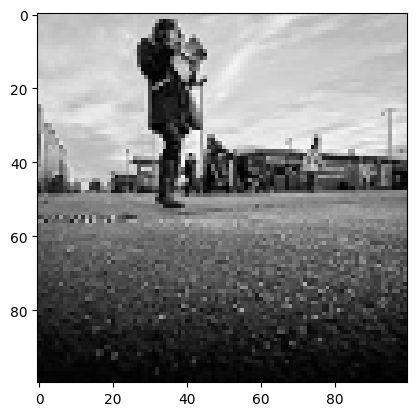

In [22]:
index = np.random.randint(X_train.shape[0])
print(class_names[y_train[index]])
plt.imshow(X_train[index]);

In [23]:
X_train_scal = X_train/255.0
X_test_scal = X_test/255.0

In [24]:
IMAGE_SIZE

(100, 100)

In [25]:
X_train_scal.shape

(14034, 100, 100, 3)

In [ ]:
# 32 filtros convolucionales tamaño 3x3 con activación relu
# maxpooling 2x2
# 64 filtros convolucionales 3x3 activación relu
# maxpooling 2x2
# entrada a la fully connected
# 1 capa con 512 neuronas con activación relu
# capa de salida para clasificar los 6 paisajes

# prográmalo tú :-)

In [28]:
# Primera capa conv
# 3 porque tenemos 3 capas RGB
# 32 porque hemos elegido en esta capa de convolución hacer 32 filtros
# 3*3 porque en cada filtro tenemos una matriz de 3*3 pixeles
# 32 bias
3*32*3*3 + 32

896

In [29]:
# Segunda capa conv
# 32 porque tenemos 32 filtros en el output de la anterior capa
# 64 porque hemos elegido en esta capa de convolución hacer 64 filtros
# 3*3 porque en cada filtro tenemos una matriz de 3*3 pixeles
# 64 bias
32*64*3*3 + 64

18496

In [30]:
2304*128 + 128

295040

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

def crear_modelo_paisajes(input_shape=(150, 150, 3)):
    model = models.Sequential([
        # 1. Primera capa convolucional: 32 filtros de 3x3, ReLU
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        # Maxpooling 2x2
        layers.MaxPooling2D((2, 2)),

        # 2. Segunda capa convolucional: 64 filtros de 3x3, ReLU
        layers.Conv2D(64, (3, 3), activation='relu'),
        # Maxpooling 2x2
        layers.MaxPooling2D((2, 2)),

        # 3. Entrada a la Fully Connected (Aplanado)
        layers.Flatten(),

        # 4. Capa densa de 512 neuronas, ReLU
        layers.Dense(512, activation='relu'),

        # 5. Capa de salida para 6 paisajes (Softmax para clasificación multiclase)
        layers.Dense(6, activation='softmax')
    ])
    
    return model

# Instanciar y ver el resumen de parámetros
model = crear_modelo_paisajes()

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    42,467,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,490,310 (162.09 MB)

 Trainable params: 42,490,310 (162.09 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
modelo.compile(
    optimizer='adam',
    # Usamos sparse si tus etiquetas son enteros (0, 1, 2, 3, 4, 5)
    # Si son One-Hot use 'categorical_crossentropy'
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)


# history = modelo.fit(
#     train_images, train_labels, 
#     epochs=10, 
#     validation_data=(test_images, test_labels)
# )

In [ ]:
# optimizador Adam, es un clasificador multiclase, mira su accuracy


In [33]:
# entreno 30 épocas para conseguir un score cercano a 0.8
# batch 256 limitación de memoria

In [ ]:
history = modelo.fit(
     train_images, train_labels, 
     epochs=30,
     batch_size=256,
     validation_data=(test_images, test_labels)
)

NameError: name 'train_images' is not defined

In [ ]:
# batch size de 256, 30 épocas, un 10% para validación


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 190ms/step - accuracy: 0.4773 - loss: 1.5725 - val_accuracy: 0.5969 - val_loss: 1.0658
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.6791 - loss: 0.8323 - val_accuracy: 0.6980 - val_loss: 0.8398
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7538 - loss: 0.6868 - val_accuracy: 0.7158 - val_loss: 0.7935
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8024 - loss: 0.5538 - val_accuracy: 0.7400 - val_loss: 0.7076
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.8307 - loss: 0.4717 - val_accuracy: 0.7557 - val_loss: 0.6899
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.8551 - loss: 0.4059 - val_accuracy: 0.7528 - val_loss: 0.7357
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8986 - loss: 0.3059 - val_accuracy: 0.7350 - val_loss: 0.7781
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9122 - loss: 0.2663 - val_accuracy: 0.7507 -

,accuracy,loss,val_accuracy,val_loss
0,0.477276,1.572527,0.596866,1.065790
1,0.679097,0.832299,0.698006,0.839818
2,0.753840,0.686802,0.715812,0.793540
3,0.802375,0.553765,0.740029,0.707592
4,0.830720,0.471715,0.755698,0.689936
5,0.855107,0.405865,0.752849,0.735679
6,0.898575,0.305915,0.735043,0.778103
7,0.912193,0.266294,0.750712,0.743194
8,0.937055,0.201630,0.756410,0.810391
9,0.954078,0.155445,0.766382,0.839987


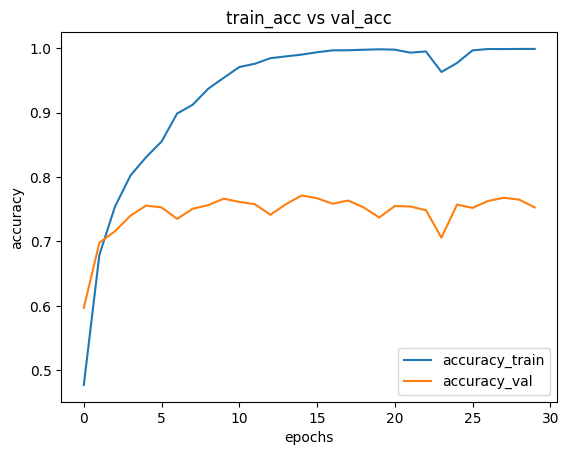

In [36]:
plt.figure()
plt.plot(df_hist['accuracy'], label="accuracy_train")
plt.plot(df_hist['val_accuracy'], label="accuracy_val")
plt.title("train_acc vs val_acc")
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.legend()

In [ ]:
# mira el accuracu en test

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7733 - loss: 1.2967


In [ ]:
# obtén la matriz de predicción

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]], dtype=float32)

In [39]:
pred_labels = np.argmax(predictions, axis=1)

In [40]:
pred_labels

array([5, 5, 5, ..., 1, 1, 1])

forest


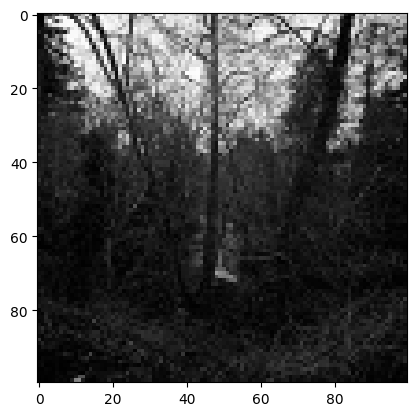

In [41]:
index=3
print(class_names[y_test[index]])
plt.imshow(X_test[index]);

In [42]:
class_names[pred_labels[index]]

'forest'

In [43]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [44]:
class_names_label

{'mountain': 0,
 'street': 1,
 'glacier': 2,
 'buildings': 3,
 'sea': 4,
 'forest': 5}

In [ ]:
# matriz de confusión

<Axes: >

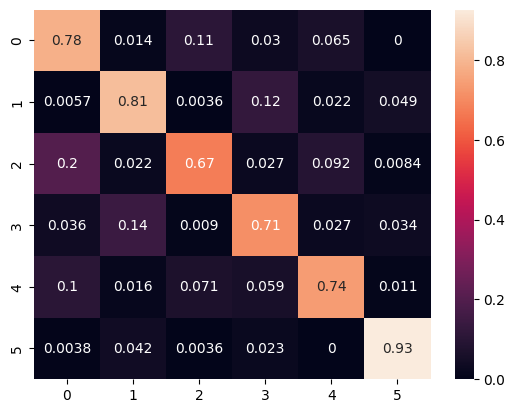

In [ ]:
# matriz de confusión